In [2]:

alpha = 0.5
beta = 0.05
pi_I = 0.30
pi_L = 0.70
probs = [0.10, 0.20, 0.40, 0.20, 0.10]
offsets = [-10, -5, 0, 5, 10]


def pi_liq(x):
    """Probabilidad de que un trader de liquidez compre/venda, dado el desvio x respecto a S0."""
    return max(alpha - beta * x, 0)


def resolver_caso(d):
    S0 = 100 + d
    valores = [S0 + o for o in offsets]
    f = dict(zip(valores, probs))

    B = S0 - d
    A = S0 + d

    x_compra = A - S0
    x_venta = S0 - B
    pLB = pi_liq(x_compra)
    pLS = pi_liq(x_venta)
    G = pi_L * (pLB * x_compra + pLS * x_venta)

    perdida_arriba = sum((V - A) * f[V] for V in valores if V > A)
    perdida_abajo = sum((B - V) * f[V] for V in valores if V < B)
    L = pi_I * (perdida_arriba + perdida_abajo)

    pi_total = G - L

    return {
        "d": d, "S0": S0, "B": B, "A": A,
        "valores_V": valores, "f(V)": probs,
        "pi_LB": pLB, "pi_LS": pLS,
        "G": round(G, 4), "L": round(L, 4), "pi": round(pi_total, 4)
    }


if __name__ == "__main__":
    for d in [2, 5, 8]:
        r = resolver_caso(d)
        print(f"\n===== CASO d = {r['d']} =====")
        print(f"S0 = {r['S0']}   Bid B = {r['B']}   Ask A = {r['A']}")
        print(f"Valores posibles de V: {r['valores_V']}  (prob: {r['f(V)']})")
        print(f"pi_LB (compra en Ask) = {r['pi_LB']}   pi_LS (venta en Bid) = {r['pi_LS']}")
        print(f"G({r['A']},{r['B']}) = {r['G']}")
        print(f"L({r['A']},{r['B']}) = {r['L']}")
        print(f"pi({r['A']},{r['B']}) = {r['pi']}")


===== CASO d = 2 =====
S0 = 102   Bid B = 100   Ask A = 104
Valores posibles de V: [92, 97, 102, 107, 112]  (prob: [0.1, 0.2, 0.4, 0.2, 0.1])
pi_LB (compra en Ask) = 0.4   pi_LS (venta en Bid) = 0.4
G(104,100) = 1.12
L(104,100) = 0.84
pi(104,100) = 0.28

===== CASO d = 5 =====
S0 = 105   Bid B = 100   Ask A = 110
Valores posibles de V: [95, 100, 105, 110, 115]  (prob: [0.1, 0.2, 0.4, 0.2, 0.1])
pi_LB (compra en Ask) = 0.25   pi_LS (venta en Bid) = 0.25
G(110,100) = 1.75
L(110,100) = 0.3
pi(110,100) = 1.45

===== CASO d = 8 =====
S0 = 108   Bid B = 100   Ask A = 116
Valores posibles de V: [98, 103, 108, 113, 118]  (prob: [0.1, 0.2, 0.4, 0.2, 0.1])
pi_LB (compra en Ask) = 0.09999999999999998   pi_LS (venta en Bid) = 0.09999999999999998
G(116,100) = 1.12
L(116,100) = 0.12
pi(116,100) = 1.0


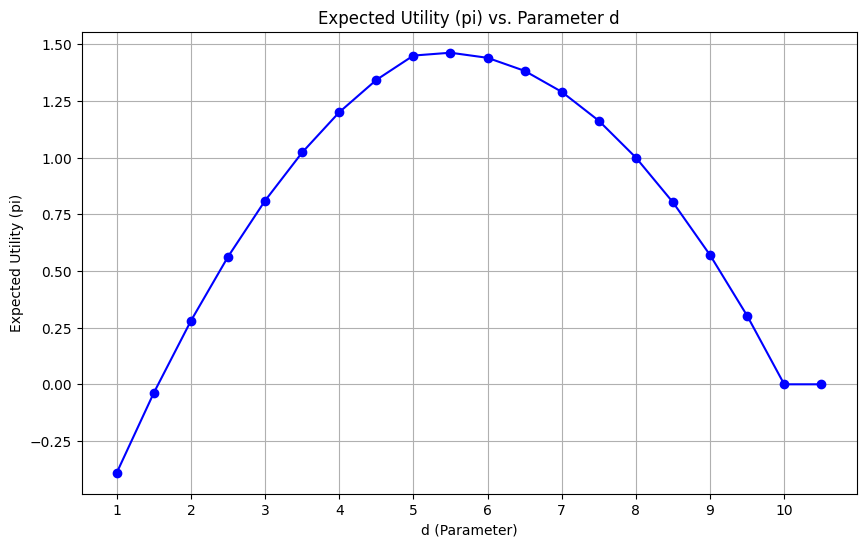

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Define a range for 'd' to plot the curve
d_values = np.arange(1, 11, 0.5) # From 1 to 10 with 0.5 step
pi_values = []

for d_val in d_values:
    result = resolver_caso(d_val)
    pi_values.append(result['pi'])

# Plotting the curve
plt.figure(figsize=(10, 6))
plt.plot(d_values, pi_values, marker='o', linestyle='-', color='b')
plt.title('Expected Utility (pi) vs. Parameter d')
plt.xlabel('d (Parameter)')
plt.ylabel('Expected Utility (pi)')
plt.grid(True)
plt.xticks(np.arange(1, 11, 1))
plt.show()